In [ ]:
import os
import openai
import pandas as pd
import matplotlib.pyplot as plt


api_key = os.getenv("OPENAI_API_KEY")

if not api_key:
    raise ValueError("Missing OpenAI API key. Set OPENAI_API_KEY as an environment variable.")

client = openai.OpenAI(api_key=api_key)

In [2]:
df = pd.read_csv('expenses.csv')
print(df.head())

         Date         Description     Type  Money (£)
0  01/11/2024     Hang Sing Hong   Expense       5.43
1  01/11/2024  TESCO STORES 6479   Expense       5.50
2  01/11/2024  TESCO STORES 5517   Expense       8.00
3  01/11/2024    Mr Miyagi Sushi   Expense      13.50
4  04/11/2024  TESCO STORES 5106   Expense      18.21


In [3]:
expenses_df = df[df['Type'] != 'Income'] 

# Calculate total sum of expenses (excluding income)
total_expenses = expenses_df[expenses_df["Type"] == "Expense"]["Money (£)"].sum()

print(total_expenses)

1923.9499999999998


In [7]:

df = pd.read_csv('expenses.csv')

def clean_description(desc):
    return desc.strip().upper() 

df["Description"] = df["Description"].apply(clean_description)

def categorize_expense(description):
    prompt = f"""  
    Categorize the following expense description into one of these categories:  
    [Groceries, Dining, Subscriptions, Rent, Shopping, Transport, Miscellaneous].

    Description: {description}
    Respond with only the category name.  
    """

    try:
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",  # Correct model name
            messages=[{"role": "user", "content": prompt}],  # Correct format for messages
            max_tokens=10
        )

        return response.choices[0].message.content.strip()  # Correct way to access the response

    except Exception as e:
        print(f"Error: {e}")
        return "Miscellaneous"  # Default category in case of an error

# Apply categorization
df['Category'] = df['Description'].apply(categorize_expense)

# Drop duplicates based on Description and Category
df = df.drop_duplicates(subset=["Description", "Category"])

# Show unique descriptions for each category
for category in df["Category"].unique():
    print(f"\n🟢 Unique Values in Category: {category}")
    print(df[df["Category"] == category]["Description"].unique())

# Display the first few rows of the DataFrame
print(df.head())


🟢 Unique Values in Category: Dining
['HANG SING HONG' 'MR MIYAGI SUSHI' 'MCDONALDS' 'HAPPY SEASONS CHIN'
 'KIMPTON CLOCKTOWER' 'SUMUP *TASTEEZ' 'HUA MEI ORIENTAL S'
 'ZETTLE_*THE FOOD H' 'OLD HALL HOTEL' 'THE YORK' 'J W BARS LTD'
 '200 DEGREES COFFEE']

🟢 Unique Values in Category: Groceries
['TESCO STORES 6479' 'TESCO STORES 5517' 'TESCO STORES 5106'
 'ZETTLE_*THE FOOD H' 'PANDAFRESH SHEFFIE']

🟢 Unique Values in Category: Shopping
['OSEYO' 'AMZNMKTPLACE*T15A8' 'EDE AND RAVENSCROF' 'POUNDLAND LTD'
 'MARKS&SPENCER PLC' 'HULLEYS OF BASLOW']

🟢 Unique Values in Category: Miscellaneous
['WONSIL CHOI' 'YUFAN CHEN' 'OSCAR SIBANDA' 'THE GYM LTD' 'AN-NI CHEN'
 'SALARY' 'CAXCO LTD' 'CHILLI FLOW SH LTD' 'TESTING EXAM VUE*M'
 'MINGTAO HUANG']

🟢 Unique Values in Category: Subscriptions
['CIRCUIT UK - APP 1' 'AMAZON PRIME*T994W' 'GOOGLE ONE'
 'AMAZON PRIME*EA7L3' 'THE GYM LTD']

🟢 Unique Values in Category: Transport
['SHALESMOOR LOCAL E']

🟢 Unique Values in Category: Rent
['RENT']
         Dat

In [8]:
correction_dict = {
    "HANG SING HONG": "Groceries",
    "HUA MEI ORIENTAL S": "Groceries"
}

df["Category"] = df.apply(lambda row: correction_dict.get(row["Description"], row["Category"]), axis=1)

for category in df["Category"].unique():
    print(f"\n🟢 Category: {category}")
    print(df[df["Category"] == category]["Description"].unique())


🟢 Category: Groceries
['HANG SING HONG' 'TESCO STORES 6479' 'TESCO STORES 5517'
 'TESCO STORES 5106' 'HUA MEI ORIENTAL S' 'ZETTLE_*THE FOOD H'
 'PANDAFRESH SHEFFIE']

🟢 Category: Dining
['MR MIYAGI SUSHI' 'MCDONALDS' 'HAPPY SEASONS CHIN' 'KIMPTON CLOCKTOWER'
 'SUMUP *TASTEEZ' 'ZETTLE_*THE FOOD H' 'OLD HALL HOTEL' 'THE YORK'
 'J W BARS LTD' '200 DEGREES COFFEE']

🟢 Category: Shopping
['OSEYO' 'AMZNMKTPLACE*T15A8' 'EDE AND RAVENSCROF' 'POUNDLAND LTD'
 'MARKS&SPENCER PLC' 'HULLEYS OF BASLOW']

🟢 Category: Miscellaneous
['WONSIL CHOI' 'YUFAN CHEN' 'OSCAR SIBANDA' 'THE GYM LTD' 'AN-NI CHEN'
 'SALARY' 'CAXCO LTD' 'CHILLI FLOW SH LTD' 'TESTING EXAM VUE*M'
 'MINGTAO HUANG']

🟢 Category: Subscriptions
['CIRCUIT UK - APP 1' 'AMAZON PRIME*T994W' 'GOOGLE ONE'
 'AMAZON PRIME*EA7L3' 'THE GYM LTD']

🟢 Category: Transport
['SHALESMOOR LOCAL E']

🟢 Category: Rent
['RENT']


In [16]:
df['Type'].unique()

array(['Expense', 'Income'], dtype=object)

In [20]:
expenses_df= df[df['Type']!= 'Income']
expenses_df.head()

,Date,Description,Type,Money (£),Category
0,01/11/2024,HANG SING HONG,Expense,5.43,Groceries
1,01/11/2024,TESCO STORES 6479,Expense,5.50,Groceries
2,01/11/2024,TESCO STORES 5517,Expense,8.00,Groceries
3,01/11/2024,MR MIYAGI SUSHI,Expense,13.50,Dining
4,04/11/2024,TESCO STORES 5106,Expense,18.21,Groceries


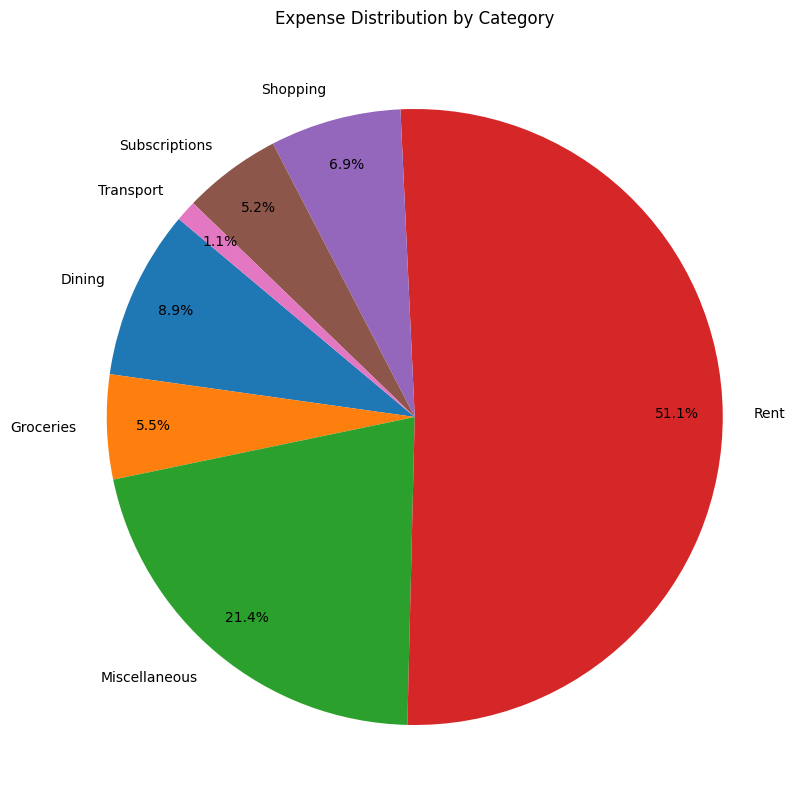

In [18]:
category_expense = expenses_df.groupby("Category")["Money (£)"].sum()
plt.figure(figsize = (10,10))
plt.pie(
    category_expense, 
    labels=category_expense.index, 
    autopct="%1.1f%%", 
    startangle=140, 
    pctdistance=0.85
)

plt.title("Expense Distribution by Category")
plt.show()


/var/folders/y0/v8s1rk113f5gqq_dvtthdf840000gn/T/ipykernel_19061/3710848647.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  expenses_df["Date"] = pd.to_datetime(expenses_df["Date"], format="%d/%m/%Y")


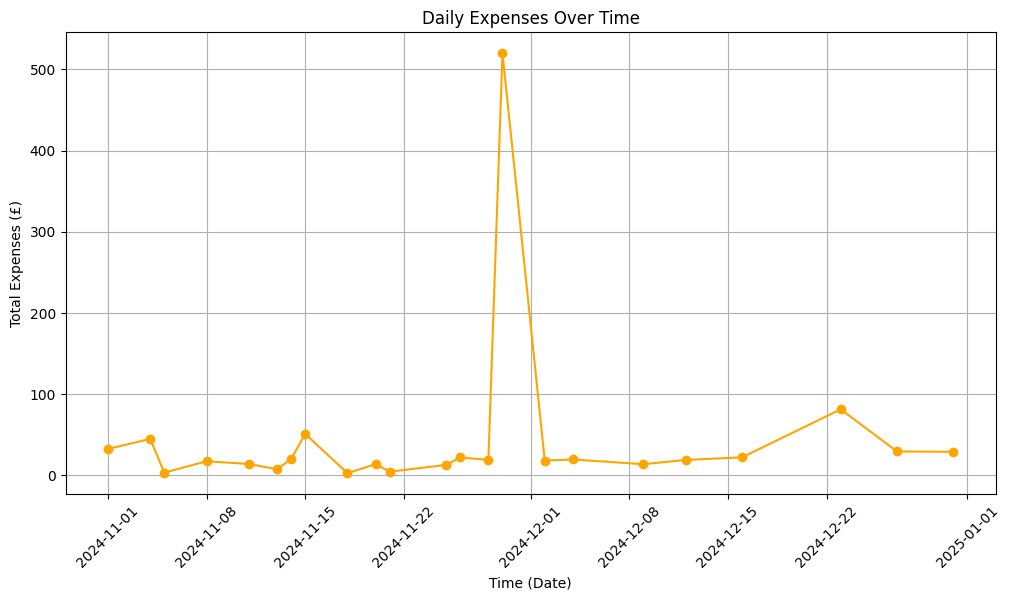

In [21]:
expenses_df["Date"] = pd.to_datetime(expenses_df["Date"], format="%d/%m/%Y")

# Ensure dates are sorted
expenses_df = expenses_df.sort_values(by="Date")

expenses_by_date = expenses_df.groupby("Date")["Money (£)"].sum()


plt.figure(figsize=(12, 6))
plt.plot(expenses_by_date.index, expenses_by_date, marker="o", linestyle="-", color="orange")

plt.xticks(rotation=45)
plt.xlabel("Time (Date)")
plt.ylabel("Total Expenses (£)")
plt.title("Daily Expenses Over Time")
plt.grid(True)
plt.show()

In [23]:

# Find the first and last recorded months
expenses_df.loc[:, "Date"] = pd.to_datetime(expenses_df["Date"], format="%d/%m/%Y")
start_month = expenses_df["Date"].min().strftime("%Y-%m")
end_month = expenses_df["Date"].max().strftime("%Y-%m")

# Count the number of unique months
num_months = len(expenses_df["Date"].dt.to_period("M").unique())
print(start_month)
print(end_month)
print(num_months)

# Calculate average monthly expenses
avg_monthly_expenses = total_expenses / num_months 

print(f"Number of months detected: {num_months}")
print(f"Total expenses (excluding income): £{total_expenses:.2f}")
print(f"Average monthly expenses: £{avg_monthly_expenses:.2f}")

2024-11
2024-12
2
Number of months detected: 2
Total expenses (excluding income): £1923.95
Average monthly expenses: £961.97


In [24]:
financial_summary = f"""
I have a monthly salary of £2083. My expense distribution is based on {num_months} months ({start_month} to {end_month}).

- Rent: 52.3%
- Miscellaneous: 21.8%
- Dining: 10.0%
- Shopping: 8.6%
- Groceries: 4.8%
- Other categories (Transport, Subscriptions, Accommodation): Less than 2% each.

Total Expenses Over {num_months} Months: £{total_expenses}
Average Monthly Expenses: £{avg_monthly_expenses:.2f}

Key observations:
1. Rent is more than half of my total expenses.
2. A large portion of my spending falls into Miscellaneous, which might contain unnecessary expenses.


### Request:
Based on my **average monthly expenses (£{avg_monthly_expenses:.2f})**, provide financial advice on:
- How to **reduce unnecessary expenses**.
- Whether my spending is balanced for my salary (£2083/month).
- How I can save more effectively or invest wisely.
"""

# Send to LLM
response = client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=[{"role": "user", "content": financial_summary}],
    max_tokens=500
)

# Print the response
print(response.choices[0].message.content.strip())

Based on your expense distribution, it seems like there may be room to reduce unnecessary expenses in the Miscellaneous category, which accounts for a significant portion of your spending. To reduce these expenses, you could track your spending carefully to identify areas where you can cut back. This could involve creating a budget and being more mindful of your spending habits.

Given that your rent is more than half of your total expenses, it may be worth considering if there are ways to lower your rent costs. This could include finding a more affordable living situation or exploring options such as house-sharing to split costs.

In terms of whether your spending is balanced for your salary of £2083/month, it appears that your expenses are slightly higher than half of your income. While this may be manageable, it's always a good idea to aim for a lower expense-to-income ratio to ensure you have enough room for savings and unexpected expenses.

To save more effectively or invest wisel

In [25]:
#now have 10000 pounds in saving

monthly_savings = 2083 - avg_monthly_expenses

target_savings = 490000  # your financial goal
current_savings = 10000  # your current savings

months_to_target = (target_savings-current_savings)/monthly_savings

current_age = 30

retirement_age = current_age+ (months_to_target / 12)

print(f"monthly_savings: £{monthly_savings:.2f}")
print(f"Months to Reach Target:£{months_to_target:.1f}")
print(f"Retirement Age: {retirement_age:.1f}")

monthly_savings: £1121.03
Months to Reach Target:£428.2
Retirement Age: 65.7


In [26]:
advanced_financial_summary = f"""
I have a monthly salary of £2083. My expense distribution is based on {num_months} months ({start_month} to {end_month}).

- Rent: 52.3%
- Miscellaneous: 21.8%
- Dining: 10.0%
- Shopping: 8.6%
- Groceries: 4.8%
- Other categories (Transport, Subscriptions, Accommodation): Less than 2% each.

### Current Financial Details
- Total Expenses Over {num_months} Months:** £{total_expenses:.2f}
- Average Monthly Expenses: £{avg_monthly_expenses:.2f}
- Monthly Savings:£{monthly_savings}
- Months to Save £490,000: {months_to_target:.1f} months (~ {months_to_target/12:.1f} years)
- Projected Retirement Age at Current Savings Rate: {retirement_age:.1f} years old

### **Advanced Financial Questions**
1. **How can I optimize my savings to reach my £49,000 goal faster?**
2. **How should I allocate my savings to maximize returns while managing risk?**
3. **What are the best passive income opportunities based on my current financial position?**
4. **How can I prepare for financial emergencies while still saving effectively?**
5. **If I want to retire at 40, what would be the required monthly savings rate and investment strategy?**
"""

response = client.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=[{"role": "user", "content": advanced_financial_summary}],
    max_tokens=800
)


print(response.choices[0].message.content.strip())


1. To optimize your savings and reach your £49,000 goal faster, you could consider reducing expenses in certain categories such as dining, shopping, or miscellaneous expenses. Cutting back on non-essential spending and reallocating those funds towards savings could help you reach your goal sooner.

2. When allocating your savings to maximize returns while managing risk, consider diversifying your investments across different asset classes such as stocks, bonds, and real estate. You could also consider investing in low-cost index funds or ETFs to spread out risk while potentially earning higher returns over the long term.

3. Some passive income opportunities based on your current financial position could include investing in dividend-paying stocks, real estate crowdfunding platforms, or peer-to-peer lending. These options can provide additional income streams without requiring active involvement on your part.

4. To prepare for financial emergencies while still saving effectively, cons

In [50]:
questions = [
    "Do you prefer long-term financial planning, or do you focus on short-term needs?",
    "If you were given an extra £1,000, how would you invest or use it?",
    "What is your main financial goal right now?",
    "How much risk are you comfortable taking with your investments? (low/medium/high)"
]

def ask_user_questions():
    responses = []
    print("💬 Please answer the following financial questions:")

    for question in questions:
        response = input(f"{question}\n Your answer: ")
        responses.append(response)
    return responses

# Classify Customer Type Using LLM
def classify_customer(responses):
    prompt = f"""
    Based on the following responses, categorize the user as one of these four types:
    - Long-Term Planner
    - Short-Term Spender
    - Risk-Taker
    - Conservative Investor

    If the responses are unclear or do not match these categories, classify as "Mixed-Type" and explain.

    ### User's Answers:
    1. {questions[0]} - {responses[0]}
    2. {questions[1]} - {responses[1]}
    3. {questions[2]} - {responses[2]}
    4. {questions[3]} - {responses[3]}

    Provide the category name with a short explanation.
    """
    
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=500
    )

    full_response = response.choices[0].message.content.strip()

    # Extract the classification label (e.g., "Mixed-Type")
    customer_type = full_response.split("\n")[0].strip()

    # Extract the explanation (everything after the label)
    explanation = "\n".join(full_response.split("\n")[1:]).strip()

    return customer_type, explanation

def recommend_financial_products(customer_type):
    recommendations = {
        "Long-Term Planner": ["Retirement Planning", "Index Fund Investing", "Pension Schemes"],
        "Short-Term Spender": ["Budgeting Apps", "High-Yield Savings Accounts", "Short-Term Investment Funds"],
        "Risk-Taker": ["Cryptocurrency Investments", "High-Risk Stocks", "Angel Investing"],
        "Conservative Investor": ["Bonds & Fixed Deposits", "Real Estate Investment", "Low-Risk Mutual Funds"],
        "Mixed-Type": [
            "Diversified Mutual Funds or ETFs",
            "Robo-Advisory Services",
            "High-Yield Savings Accounts",
            "Retirement Savings Plans (e.g., IRA)",
            "Financial Planning Consultations"
        ]
    }

    # Return recommendations, or a default value if the category is not found
    return recommendations.get(customer_type, ["General Budgeting & Savings Advice"])

In [51]:
def financial_chatbot():
    print("💬 Welcome to the AI Financial Advisor!\n")

    # Get user responses
    responses = ask_user_questions()

    # Classify the customer
    customer_type, explanation = classify_customer(responses)
    print(f"\n➡️ You are classified as: **{customer_type}**\n")
    print(f"{explanation}\n")

    # Recommend financial products
    products = recommend_financial_products(customer_type)

    print("\n📌 Recommended Financial Products for You:")
    for product in products:
        print(f"   - {product}")

# Run the chatbot
financial_chatbot()

💬 Welcome to the AI Financial Advisor!

💬 Please answer the following financial questions:

➡️ You are classified as: **Short-Term Spender**

Explanation: The user mentioned a focus on short-term needs, preferring to use extra money rather than invest it. While their main financial goal is investment, their comfort level with risk is medium, indicating a preference for shorter-term gains.


📌 Recommended Financial Products for You:
   - Budgeting Apps
   - High-Yield Savings Accounts
   - Short-Term Investment Funds
